## Exercises

1. Generate a dataset that is NOT linearly separable (e.g., two concentric circles). Train logistic regression and observe its failure. Then add polynomial features (x1^2, x2^2, x1*x2) and train again. Show that the accuracy improves.
2. Implement a multi-class confusion matrix for the 3-class softmax model. Compute per-class precision and recall. Which class is hardest to classify?
3. Build an ROC curve from scratch. For 100 threshold values from 0 to 1, compute the true positive rate and false positive rate. Calculate the AUC (area under the curve) using the trapezoidal rule.



### 1. Ans :

Step 1: Generate non-linearly separable data

Example: two concentric circles.
```
Imagine target like this:

        O O O O O
     O             O
   O                 O
  O        X X        O
  O      X X X X      O
  O        X X        O
   O                 O
     O             O
        O O O O O
Outer circle = Class 0
Inner circle = Class 1
```

Can single straight line separate circles?

No.

No matter where line goes, both classes appear both sides.

In [1]:
# generate no lineaerly seperatable data 
from sklearn.datasets import make_circles

In [2]:
X, y = make_circles(random_state=42,factor=0.6)

In [4]:
X

array([[-3.21496077e-01, -5.06596755e-01],
       [ 5.57865892e-01,  2.20874732e-01],
       [-4.85410197e-01,  3.52671151e-01],
       [ 8.09016994e-01, -5.87785252e-01],
       [ 7.28968627e-01, -6.84547106e-01],
       [ 1.87381315e-01, -9.82287251e-01],
       [-9.29776486e-01,  3.68124553e-01],
       [-4.85410197e-01, -3.52671151e-01],
       [ 3.09016994e-01,  9.51056516e-01],
       [ 1.00000000e+00,  0.00000000e+00],
       [-6.37423990e-01,  7.70513243e-01],
       [-8.09016994e-01, -5.87785252e-01],
       [-5.81149897e-01,  1.49213932e-01],
       [-5.35826795e-01, -8.44327926e-01],
       [ 1.85410197e-01, -5.70633910e-01],
       [ 8.76306680e-01,  4.81753674e-01],
       [-5.95268821e-01, -7.51999401e-02],
       [-5.81149897e-01, -1.49213932e-01],
       [ 6.27905195e-02,  9.98026728e-01],
       [-7.28968627e-01, -6.84547106e-01],
       [ 4.85410197e-01,  3.52671151e-01],
       [ 3.76743117e-02, -5.98816037e-01],
       [-9.92114701e-01, -1.25333234e-01],
       [ 5.

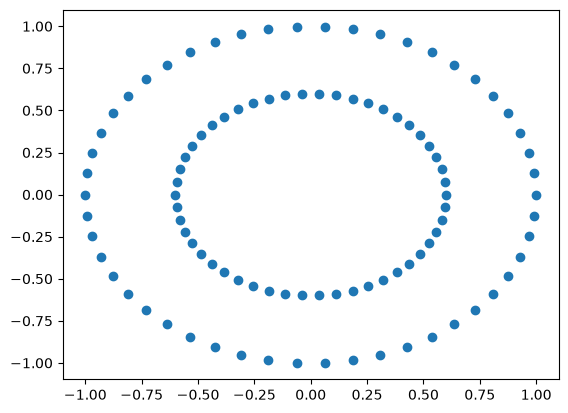

In [7]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1])

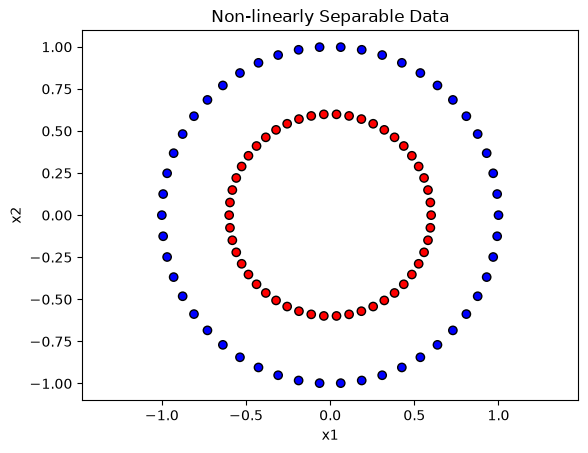

In [8]:

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="bwr",
    edgecolors="k"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Non-linearly Separable Data")
plt.axis("equal")
plt.show()

In [9]:
# now train lg and observe failure 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [11]:
model_lg=LogisticRegression()
model_lg.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [12]:
model_lg.score(X_test,y_test) # -> 0.3333333333333333 successfully fails

0.3333333333333333

Text(0.5, 1.0, 'Lower Logistic Regression Result (Without Polynomial)')

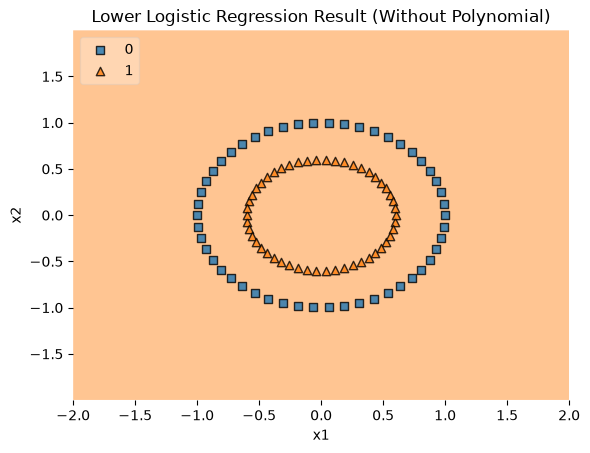

In [20]:
# Let's Plot :) the prediction line
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X,y,clf=model_lg,legend=2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Lower Logistic Regression Result (Without Polynomial)")

Text(0.5, 1.0, 'Lower Logistic Regression Result (Without Polynomial)')

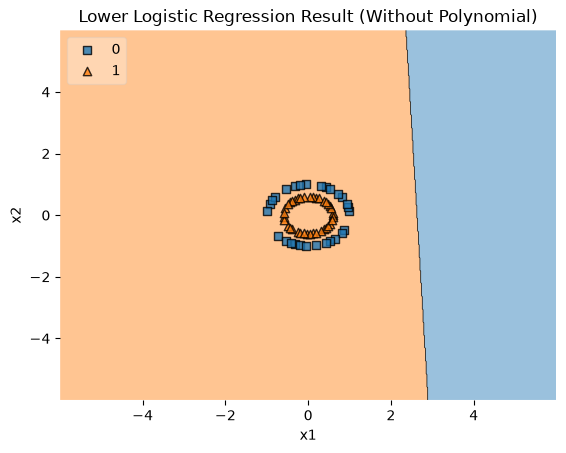

In [23]:
# Let's Plot :) the prediction line
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X_train,y_train,clf=model_lg,legend=2,zoom_factor=0.2) # with zoom factor the line is visiable , :) 
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Lower Logistic Regression Result (Without Polynomial)")

out of the world :) 

**Let's try with polynomial features**

In [13]:
from sklearn.preprocessing import PolynomialFeatures

In [24]:
poly=PolynomialFeatures(degree=2,include_bias=True)

In [25]:
X_train_poly=poly.fit_transform(X_train)

In [31]:
X_test_poly=poly.fit_transform(X_test)

In [27]:
model_poly=LogisticRegression()

In [28]:
model_poly.fit(X_train_poly,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [32]:
model_poly.score(X_test_poly,y_test)

1.0

In [36]:
# # Let's Plot :) the prediction line
# from mlxtend.plotting import plot_decision_regions

# plot_decision_regions(X_train_poly,y_train,clf=model_poly,legend=2) # with zoom factor the line is visiable , :) 
# plt.xlabel("x1")
# plt.ylabel("x2")
# plt.title("Lower Logistic Regression Result (Without Polynomial)")

<Axes: >

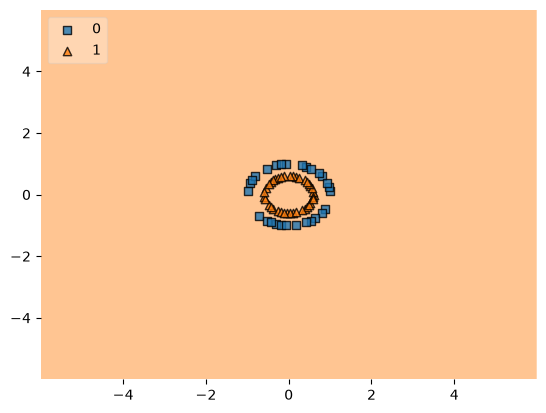

In [42]:
plot_decision_regions(
    X_train_poly,
    y_train, 
    clf=model_poly, 
    feature_index=[1,2], 
    filler_feature_values={0:1,3:0,4:0,5:0}, 
    filler_feature_ranges={0:1,3:1,4:1,5:1},)

In [44]:
import numpy as np

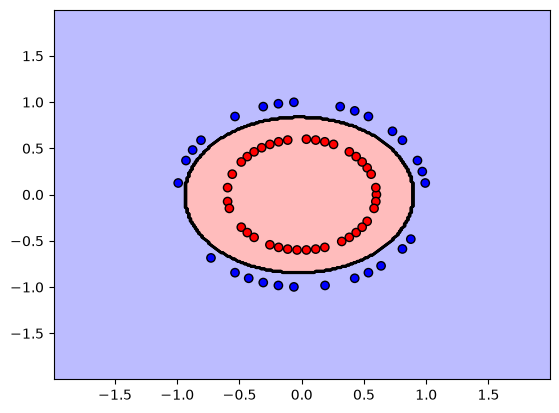

In [45]:
x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_poly = poly.transform(grid)

Z = model_poly.predict(grid_poly)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="bwr")
plt.contour(xx, yy, Z, colors="k")

plt.scatter(
    X_train[:,0],
    X_train[:,1],
    c=y_train,
    cmap="bwr",
    edgecolors="k"
)

plt.show()

### 2. Ans

In [54]:
class_names=["cat","dog","cow"]

In [55]:
y_predicted =[0,1,0,2,1,0,1,2]
y_true =     [0,1,1,2,1,1,0,2]

In [57]:
cm=np.zeros((3,3))
cm

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [60]:
for pred,actual in zip(y_predicted,y_true):
    # try to iterate with data mannually
    cm[actual][pred]+=1

In [61]:
cm

array([[2., 0., 1.],
       [0., 2., 0.],
       [1., 0., 0.]])

In [67]:
# precesion recall
precision=[]
recall=[]
for c in range(len(class_names)):
    TP = cm[c][c]
    FP = sum(cm[r][c] for r in range(len(class_names)) if r!=c)
    FN = sum(cm[k][c] for k in range(len(class_names)) if k!=c)
    
    if TP+FP ==0:
        precision.append(0)
    else:
        precision.append(TP/(TP+FP))
        
    if TP+FN==0:
        recall.append(0)
    else:
        recall.append(TP/(TP+FN))
    

In [68]:
for c in range(len(class_names)):
    print(f"Class {c}")
    print(f"Precision: {precision[c]:.4f}")
    print(f"Recall: {recall[c]:.4f}")

Class 0
Precision: 0.6667
Recall: 0.6667
Class 1
Precision: 1.0000
Recall: 1.0000
Class 2
Precision: 0.0000
Recall: 0.0000


In [69]:
hardest = np.argmin(recall)

print("Hardest class:", hardest)

Hardest class: 2


```
        Pred
         0  1  2
A 0     6  2  1
A 1     3  5  2
A 2     1  4  7

Class 0
TP = 6
FP = 4
FN = 3

Class 1
TP = 5
FP = 6
FN = 5

Class 2
TP = 7
FP = 3
FN = 5

```


TP = diagonal

FP = rest of same column

FN = rest of same row


### 3. Ans

In [46]:
threshholds=np.linspace(0,1,100)

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Ground truth labels
y_true = np.array([1, 0, 1, 0, 1, 0, 1, 1, 0, 0])

# Model predicted probabilities
y_prob = np.array([0.99, 0.85, 0.78, 0.72, 0.65,
                   0.60, 0.55, 0.42, 0.30, 0.10])

# 100 thresholds
thresholds = np.linspace(0, 1, 100)

tprs = []
fprs = []

for threshold in thresholds:

    # Convert probabilities into class predictions
    y_pred = (y_prob >= threshold).astype(int)

    # Confusion matrix values
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    # True Positive Rate (Recall)
    if TP + FN == 0:
        TPR = 0
    else:
        TPR = TP / (TP + FN)

    # False Positive Rate
    if FP + TN == 0:
        FPR = 0
    else:
        FPR = FP / (FP + TN)

    tprs.append(TPR)
    fprs.append(FPR)

# Convert into numpy arrays
tprs = np.array(tprs)
fprs = np.array(fprs)

# Sort before integration
order = np.argsort(fprs)
fprs = fprs[order]
tprs = tprs[order]

# Trapezoidal Rule
auc = np.trapz(tprs, fprs)

print("AUC =", auc)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fprs, tprs, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], "--", color="red")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

AttributeError: module 'numpy' has no attribute 'trapz'